<a href="https://colab.research.google.com/github/HussamAlabrash/DSA210PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Libraries

In [29]:
!pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## 2. Data Collection


In [30]:
from google.colab import files
uploaded = files.upload()

## 3. Loading the Data

In [31]:
econ = pd.read_csv("Middle_East_Economic_Data_1990_2024_with_Oil.csv")
conflict = pd.read_csv("MiddleEast_2015-2024_Nov01.csv")

## 4. Data Preparation

The conflict dataset is aggregated to create yearly country-level indicators such as total conflict events and fatalities.

In [32]:
conflict_agg = conflict.groupby(['country', 'year']).agg({
    'event_id_cnty': 'count',
    'fatalities': 'sum'
}).reset_index()

conflict_agg.rename(columns={
    'event_id_cnty': 'conflict_events'
}, inplace=True)

## 5. Filtering Data (2015–2024)

Only overlapping years between datasets are used.

In [33]:
econ_filtered = econ[(econ['Year'] >= 2015) & (econ['Year'] <= 2024)]

## 6. Merging Datasets

The datasets are merged using country and year.

In [34]:
# Make a safe copy to avoid pandas warning
econ_filtered = econ_filtered.copy()

# Clean country names to avoid mismatches
conflict_agg['country'] = conflict_agg['country'].str.strip().str.lower()
econ_filtered['Country'] = econ_filtered['Country'].str.strip().str.lower()

# Merge datasets
merged = econ_filtered.merge(
    conflict_agg,
    left_on=['Country', 'Year'],
    right_on=['country', 'year'],
    how='left'
)

# Fill missing conflict values
merged['conflict_events'] = merged['conflict_events'].fillna(0)
merged['fatalities'] = merged['fatalities'].fillna(0)

# Preview
merged.sample(10)

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,country,year,conflict_events,fatalities
99,qatar,QAT,2024,NaN,0.209965,2.191626e+11,2.359706,76688.694174,NaN,1.267343,NaN,0.130,85.0,qatar,2024.0,1.0,0.0
118,united arab emirates,ARE,2023,106.846139,5.871841,5.226222e+11,4.301182,49850.687218,92.198840,1.626708,82.90900,2.151,80.0,united arab emirates,2023.0,4.0,0.0
23,iran,IRN,2018,29.639694,0.576106,4.119033e+11,-3.747960,4783.010673,26.975655,18.014118,76.62100,12.195,55.0,iran,2018.0,3206.0,258.0
104,saudi arabia,SAU,2019,32.159205,0.346411,8.888901e+11,1.651589,29566.793383,24.634616,-1.192986,78.31300,5.636,50.0,saudi arabia,2019.0,298.0,1043.0
45,israel,ISR,2020,27.172299,5.104751,4.107684e+11,-2.021615,44575.571905,24.064374,-0.575255,82.64878,4.169,45.0,israel,2020.0,1580.0,1.0
105,saudi arabia,SAU,2020,23.809812,0.211116,7.679512e+11,-3.804789,24338.830730,23.723348,3.372350,77.59600,7.660,45.0,saudi arabia,2020.0,121.0,54.0
24,iran,IRN,2019,22.314708,0.433348,3.479884e+11,-2.361435,3997.493545,26.277063,39.907346,76.85500,10.740,50.0,iran,2019.0,2602.0,478.0
10,egypt,EGY,2015,13.183845,2.102581,3.293666e+11,4.372019,3306.981594,21.662097,10.370490,70.13500,13.052,70.0,NaN,NaN,0.0,0.0
50,jordan,JOR,2015,36.544437,4.147202,3.858702e+10,2.496529,4042.756781,58.813475,-0.876851,75.06000,13.075,70.0,NaN,NaN,0.0,0.0
22,iran,IRN,2017,21.832931,0.983655,5.102399e+11,3.026855,6000.933464,21.322762,8.044924,76.39600,12.232,60.0,iran,2017.0,2582.0,185.0


### Conflict Events vs GDP Growth

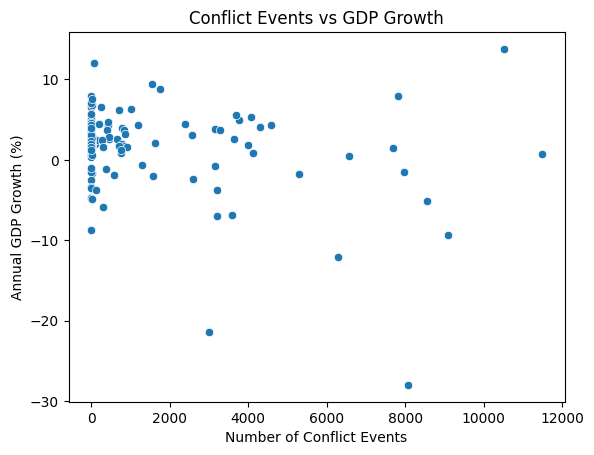

In [35]:
plt.figure()

sns.scatterplot(data=merged, x='conflict_events', y='GDP_growth_annual_pct')

plt.title("Conflict Events vs GDP Growth")
plt.xlabel("Number of Conflict Events")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot illustrates the relationship between the number of conflict events and GDP growth across Middle Eastern countries. The points appear widely dispersed, indicating that the relationship is not very strong. However, there is a slight downward trend suggesting that higher levels of conflict may be associated with lower GDP growth. Additionally, observations with very high conflict events tend to correspond with more negative or volatile GDP growth values, highlighting the potential economic instability caused by conflict.

### Fatalities vs Inflation

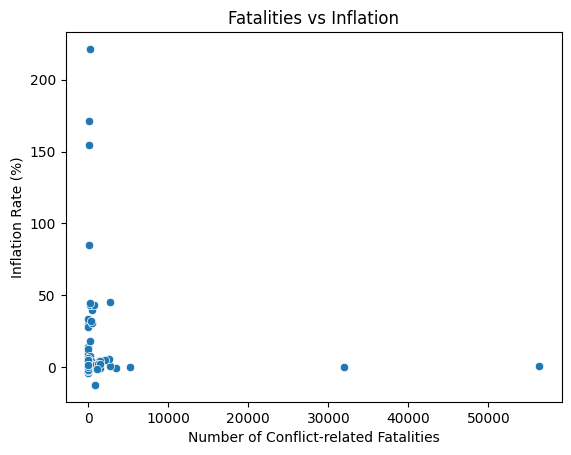

In [36]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='fatalities',
    y='Inflation_consumer_prices_annual_pct'
)

plt.title("Fatalities vs Inflation")
plt.xlabel("Number of Conflict-related Fatalities")
plt.ylabel("Inflation Rate (%)")

plt.show()

This plot examines the relationship between conflict-related fatalities and inflation rates. The data points are scattered without a clear upward or downward trend, suggesting that there is no strong relationship between fatalities and inflation. This indicates that while conflict may influence economic conditions, its direct impact on inflation is not clearly observable in this dataset.

### Oil Price vs GDP Growth

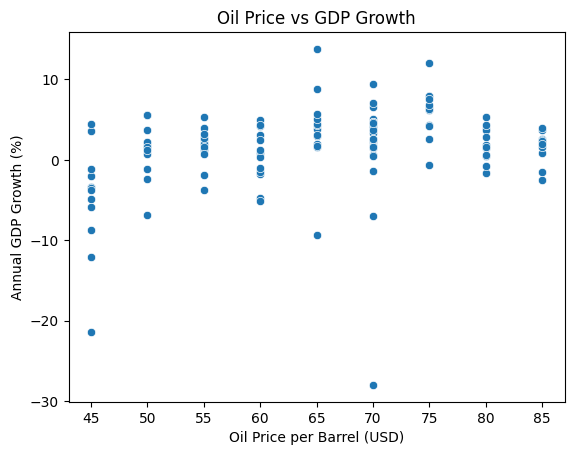

In [37]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='Brent_Oil_Price_USD_per_barrel',
    y='GDP_growth_annual_pct'
)

plt.title("Oil Price vs GDP Growth")
plt.xlabel("Oil Price per Barrel (USD)")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

### Conflict Events Over Time

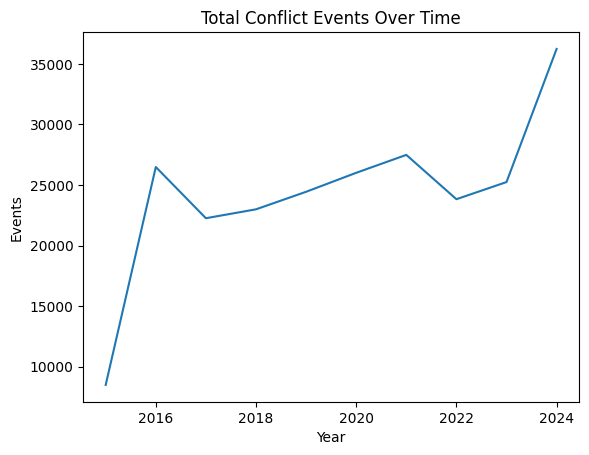

In [38]:
conflict_trend = merged.groupby('Year')['conflict_events'].sum()

plt.figure()
conflict_trend.plot()
plt.title("Total Conflict Events Over Time")
plt.xlabel("Year")
plt.ylabel("Events")
plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

### Hypothesis 1
H₀: Conflict has no effect on GDP growth  
H₁: Conflict negatively affects GDP growth

In [39]:
df = merged[['conflict_events', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.24399904799421807
P-value: 0.006534432771616528


The correlation between conflict events and GDP growth is negative (-0.244), indicating that higher levels of conflict are associated with lower GDP growth. The p-value (0.0065) is less than 0.05, which means the result is statistically significant. Therefore, we reject the null hypothesis and conclude that conflict has a negative effect on GDP growth.

### Hypothesis 2
H₀: Fatalities does not affect inflation  
H₁: Fatalities increases inflation

In [40]:
df = merged[['fatalities', 'Inflation_consumer_prices_annual_pct']].dropna()

corr, p_value = pearsonr(df['fatalities'], df['Inflation_consumer_prices_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04134737561611397
P-value: 0.6538726422751064


The correlation between fatalities and inflation is very weak (-0.041), suggesting almost no relationship between the two variables. The p-value (0.6539) is greater than 0.05, indicating that the result is not statistically significant. Therefore, we fail to reject the null hypothesis and conclude that there is no significant relationship between conflict and inflation.

### Hypothesis 3
H₀: Conflict has no effect on FDI  
H₁: Conflict reduces FDI

In [41]:
df = merged[['conflict_events', 'FDI_net_inflows_pct_GDP']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['FDI_net_inflows_pct_GDP'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.38378482552189574
P-value: 1.1763359195311098e-05


The correlation between conflict events and FDI is negative (-0.384), indicating that higher conflict levels are associated with lower foreign direct investment. The p-value (1.18e-05) is much smaller than 0.05, showing strong statistical significance. Therefore, we reject the null hypothesis and conclude that conflict reduces FDI inflows.

### Hypothesis 4
H₀: Oil price has no effect on GDP  
H₁: Oil price affects GDP

In [42]:
df = merged[['Brent_Oil_Price_USD_per_barrel', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['Brent_Oil_Price_USD_per_barrel'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.29928216968072113
P-value: 0.0007717590245511473


The correlation between oil prices and GDP growth is positive (0.299), suggesting that higher oil prices are associated with higher GDP growth. The p-value (0.00077) is less than 0.05, indicating statistical significance. Therefore, we reject the null hypothesis and conclude that oil prices have a significant effect on GDP growth.

## Conclusion

The analysis shows that conflict intensity is negatively associated with GDP growth and negatively associated with FDI inflows. However, no statistically significant relationship was found between conflict and inflation. Oil prices also play a significant role in economic performance, especially in oil-dependent countries. These findings suggest that both political instability and global oil markets are important factors influencing economic outcomes in the Middle East.